[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/20_sklearn_bases.ipynb)



# Scikit-learn : les bases

Voici le cœur du machine learning. Tout ce qui précède NumPy pour les tableaux,
Pandas pour les données, la visualisation pour explorer servait à amener les
données dans la forme qu'un modèle attend.

La force de scikit-learn est sa régularité : tous les modèles s'utilisent de
la même façon. Créer, `fit`, `predict`, `score`. Changer de modèle revient à
changer une ligne. C'est un héritage direct de la POO du notebook 09.

## Le plan

| Section | Le sujet |
|---|---|
| 1 | L'interface commune : fit, predict, score |
| 2 | La régression linéaire |
| 3 | Quand le modèle ne colle pas aux données |
| 4 | Changer de modèle en une ligne |
| 5 | La classification : le Titanic |
| 6 | Prédire sur un nouveau cas |
| 7 | Le piège du score sur les données d'entraînement |

## Trois pièges annoncés

Une variable unique doit être en `(n, 1)`, pas `(n,)` d'où les `reshape`.

Un modèle linéaire sur des données courbes donne un score trompeur : il faut
regarder le graphique, pas seulement le chiffre.

Et le score calculé sur les données d'entraînement surestime la performance
réelle. C'est la faute la plus importante du notebook.

Prérequis : le bloc NumPy, la POO du notebook 09, des bases de Pandas.

## 1. L'interface commune

Tous les modèles scikit-learn suivent le même schéma, hérité d'une classe de
base commune.

In [1]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
print(model)

LinearRegression()


Créer un modèle, c'est instancier une classe exactement comme au notebook 09.
Les hyperparamètres se passent au constructeur :

```python
LinearRegression(fit_intercept=False)
KNeighborsClassifier(n_neighbors=5)
```

Ce sont les choix qu'on fait avant l'entraînement.

Ensuite, quatre opérations, toujours les mêmes :

| Étape | Méthode | Rôle |
|---|---|---|
| Entraîner | `model.fit(X, y)` | apprend à partir des données |
| Prédire | `model.predict(X)` | applique le modèle |
| Évaluer | `model.score(X, y)` | mesure la qualité |
| Lire | `model.coef_` | les paramètres appris |

Les attributs finissant par un tiret bas `coef_`, `intercept_` sont ceux
calculés pendant `fit`. Y accéder avant lève une erreur. C'est une convention de
scikit-learn signalée au notebook 09.

## 2. La régression linéaire

Fabriquons des données qui suivent une droite, avec du bruit.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

m = 100
X = np.linspace(0, 10, m)
X.shape

(100,)

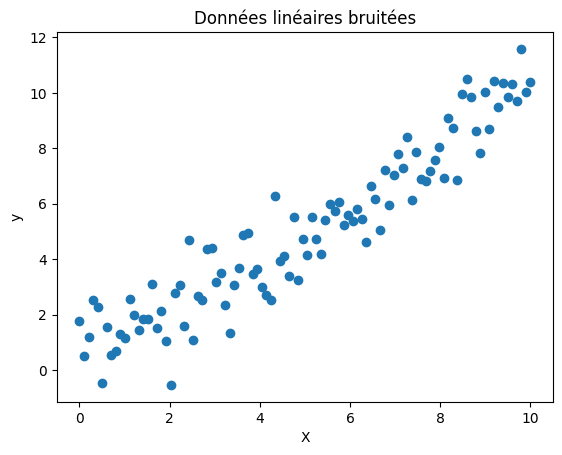

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

m = 100
X = np.linspace(0, 10, m).reshape(m, 1) # (100, 1) : le reshape est crucial
y = X + np.random.randn(m, 1)

plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Données linéaires bruitées')
plt.show()

### Le piège du reshape

`X` est en `(100, 1)`, pas `(100,)`. C'est obligatoire en scikit-learn : les
modèles attendent une matrice à deux dimensions une ligne par individu, une
colonne par variable.

Avec une seule variable, il faut donc forcer la colonne. C'est le `(n, 1)` contre
`(n,)` du notebook 10, et le broadcasting du notebook 13.

In [4]:
vecteur = np.linspace(0, 10, m) # (100,) sans reshape

try:
    LinearRegression().fit(vecteur, y)
except ValueError as e:
    print('ValueError :', str(e)[:90])

ValueError : Expected 2D array, got 1D array instead:
array=[ 0.          0.1010101   0.2020202   0.303


Le message réclame un tableau 2D. La parade est `reshape(-1, 1)`, le `-1` laissant
NumPy déduire la longueur.

### Entraîner et prédire

In [5]:
model = LinearRegression()
model.fit(X, y)

print('R² :', round(model.score(X, y), 4))
print('pente :', model.coef_.ravel())
print('ordonnée :', model.intercept_)

R² : 0.8881
pente : [0.97026731]
ordonnée : [0.20847145]


Trois choses en sortie.

Le R² mesure la qualité de l'ajustement, entre 0 et 1. Proche de 1, le modèle
explique bien les données ; proche de 0, il ne vaut pas mieux qu'une moyenne. Ici
autour de 0,89, ce qui est bon vu le bruit.

`coef_` est la pente apprise proche de 1, puisqu'on a construit `y = X + bruit`.

`intercept_` est l'ordonnée à l'origine proche de 0.

Le modèle a retrouvé la droite cachée dans les données.

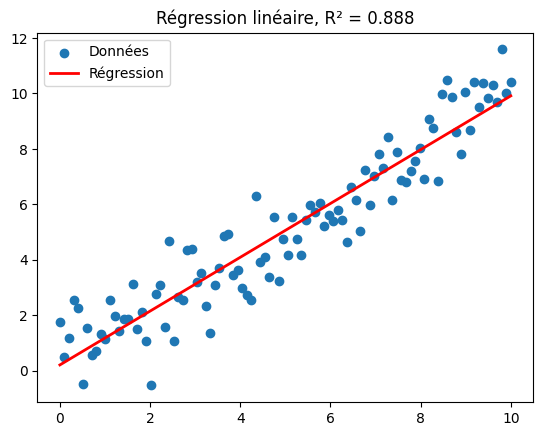

In [7]:
prediction = model.predict(X)

plt.scatter(X, y, label='Données')
plt.plot(X, prediction, c='red', lw=2, label='Régression')
plt.legend()
plt.title(f'Régression linéaire, R² = {model.score(X, y):.3f}')
plt.show()

La droite rouge passe au milieu du nuage. C'est ce que fait la régression : elle
cherche la droite qui minimise l'écart aux points, la méthode des moindres carrés.

## 3. Quand le modèle ne colle pas

Changeons les données : cette fois `y` suit une parabole, pas une droite.

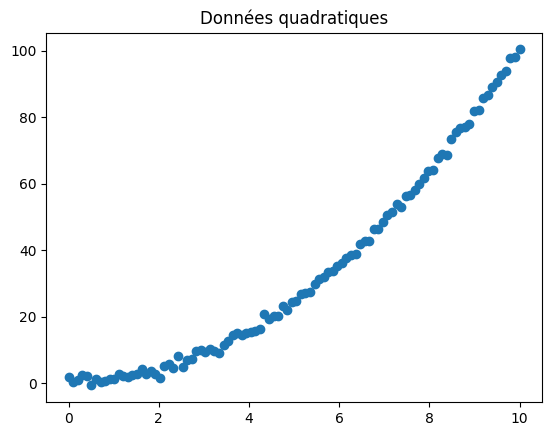

In [8]:
np.random.seed(0)

X = np.linspace(0, 10, m).reshape(m, 1)
y = X**2 + np.random.randn(m, 1) # relation quadratique

plt.scatter(X, y)
plt.title('Données quadratiques')
plt.show()

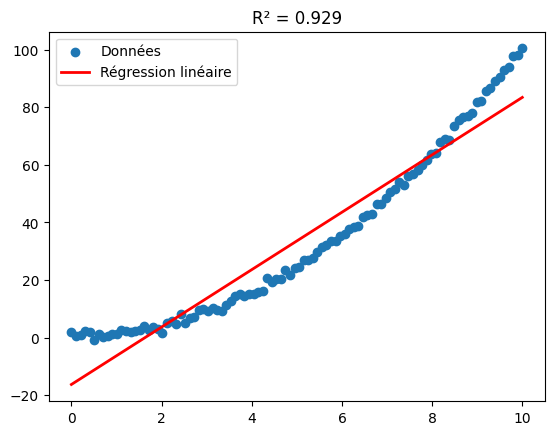

In [11]:
model = LinearRegression()
model.fit(X, y)
prediction = model.predict(X)
plt.scatter(X, y, label='Données')
plt.plot(X, prediction, c='red', lw=2, label='Régression linéaire')
plt.legend()
plt.title(f'R² = {model.score(X, y):.3f}')
plt.show()

### Le piège du score trompeur

Regarde le R² : il est élevé, autour de 0,93. On pourrait croire à un bon modèle.

Mais le graphique dit le contraire. La droite ne suit pas la courbe : elle
sous-estime au début et à la fin, surestime au milieu. Un modèle linéaire ne peut
pas épouser une parabole.

C'est la leçon centrale de cette section, et le prolongement du notebook 19 : un
chiffre ne remplace pas un graphique. Le R² dit « pas mal », l'œil dit « mauvais
choix de modèle ».

La preuve du problème apparaît dans les résidus l'écart entre réel et prédit.

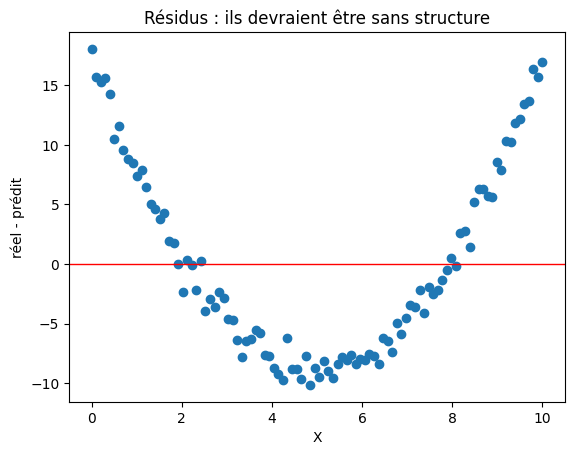

In [12]:
residus = y.ravel() - prediction.ravel()

plt.scatter(X, residus)
plt.axhline(0, color='red', lw=1)
plt.title('Résidus : ils devraient être sans structure')
plt.xlabel('X')
plt.ylabel('réel - prédit')
plt.show()

Les résidus dessinent un U au lieu d'être répartis au hasard autour de zéro.
Cette forme est la signature d'un modèle inadapté : il reste une structure que le
modèle n'a pas captée.

Un bon modèle laisse des résidus sans motif. Dès qu'ils forment une courbe, c'est
qu'un modèle plus riche conviendrait mieux.

## 4. Changer de modèle en une ligne

C'est ici que la régularité de scikit-learn paie. Essayons un modèle capable de
suivre une courbe, sans rien changer d'autre.

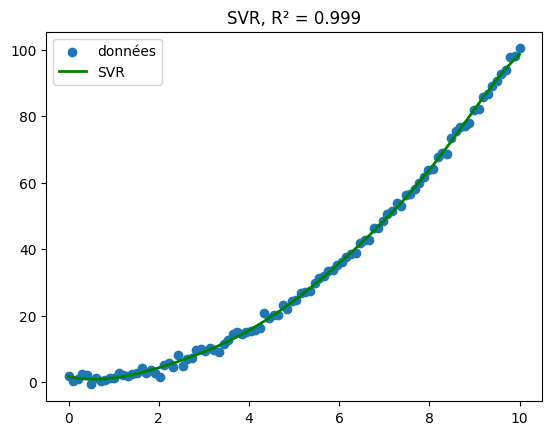

In [17]:
from sklearn.svm import SVR

model = SVR(C=100)
model.fit(X, y.ravel()) # SVR veut y en (n,), d'où le ravel

prediction = model.predict(X)

plt.scatter(X, y, label='données')
plt.plot(X, prediction, c='green', lw=2, label='SVR')
plt.legend()
plt.title(f'SVR, R² = {model.score(X, y.ravel()):.3f}')
plt.show()

Le SVR (*support vector regression*) épouse la courbe. Le seul changement de code
est la ligne de création : `SVR(C=100)` au lieu de `LinearRegression()`.

C'est tout l'intérêt de l'interface commune. `fit`, `predict`, `score` sont
identiques d'un modèle à l'autre. On peut donc en tester plusieurs sans réécrire
le code ce qui rend l'expérimentation rapide.

Deux nuances.

`y.ravel()` : certains modèles veulent `y` en `(n,)`, d'autres acceptent `(n, 1)`.
En cas d'avertissement sur la forme, `ravel()` résout le problème.

`C=100` est un hyperparamètre du SVR. Le régler change le résultat c'est le
sujet de la sélection de modèle, au notebook 21.

### Comparer plusieurs modèles

Grâce à l'interface commune, une simple boucle les compare.

In [18]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

modeles = {
    'Linéaire': LinearRegression(),
    'SVR': SVR(C=100),
    'Arbre': DecisionTreeRegressor(max_depth=3),
    'Forêt': RandomForestRegressor(n_estimators=50),
}

for nom, mod in modeles.items():
    mod.fit(X, y.ravel())
    print(f'{nom:<10} R² = {mod.score(X, y.ravel()):.3f}')

Linéaire   R² = 0.929
SVR        R² = 0.999
Arbre      R² = 0.988
Forêt      R² = 1.000


Le même code entraîne et évalue quatre modèles très différents. Aucun n'a demandé
d'adapter la syntaxe c'est la promesse de scikit-learn.

Attention toutefois : ces scores sont calculés sur les données
d'entraînement, ce qui les rend optimistes. On y revient en section 7.

## 5. La classification : le Titanic

La régression prédit un nombre. La classification prédit une catégorie ici, survivre ou non.

In [19]:
import pandas as pd
import seaborn as sns

titanic = sns.load_dataset('titanic')
print(titanic.shape)
titanic.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


On garde quatre colonnes, on retire les lignes incomplètes, et on convertit le
sexe en nombre la préparation du notebook 17.

In [20]:
titanic = titanic[['survived', 'pclass', 'age', 'sex']].copy()
titanic = titanic.dropna(axis=0)
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})

print('forme :', titanic.shape)
titanic.head()

forme : (714, 4)


,survived,pclass,age,sex
0,0,3,22.0,0
1,1,1,38.0,1
2,1,3,26.0,1
3,1,1,35.0,1
4,0,3,35.0,0


Note sur le `.copy()` et le `map`. L'ancienne écriture `replace(..., inplace=True)`
sur une tranche déclenche un avertissement de Pandas récent. Le `.copy()` suivi
d'un `map` réassigné est la façon propre elle évite le piège du
*SettingWithCopyWarning*.

### Séparer X et y

La convention universelle : `X` les variables explicatives, `y` la cible.

In [21]:
y = titanic['survived'] # ce qu'on veut prédire
X = titanic.drop('survived', axis=1) # tout le reste

print('X :', X.shape)
print('y :', y.shape)
print()
print(X.head())

X : (714, 3)
y : (714,)

   pclass   age  sex
0       3  22.0    0
1       1  38.0    1
2       3  26.0    1
3       1  35.0    1
4       3  35.0    0


`y` est ce qu'on cherche à prédire, `X` ce dont on dispose pour le faire. Ici `X`
contient classe, âge et sexe.

### Entraîner un classifieur

In [22]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
model.fit(X, y)

print('score :', round(model.score(X, y), 4))

score : 0.8305


Même interface exactement : `fit` puis `score`. Seul le modèle change `KNeighborsClassifier` au lieu de `LinearRegression`.

Pour la classification, `score` donne l'exactitude : la proportion de
prédictions correctes. Un score de 0,80 signifie 80 % de bonnes réponses.

Le KNN *k plus proches voisins* classe chaque individu selon la majorité de
ses voisins les plus proches. C'est le calcul de distances du broadcasting du
notebook 13, appliqué à la décision.

## 6. Prédire sur un nouveau cas

Un modèle entraîné sert à prédire sur des cas inédits. Écrivons une fonction qui
teste un passager fictif.

In [23]:
def survie(model, pclass=3, sex=0, age=26):
    """Prédit la survie d'un passager fictif."""
    x = np.array([pclass, sex, age]).reshape(1, 3) # une ligne, trois colonnes

    prediction = model.predict(x)
    proba = model.predict_proba(x)

    resultat = 'survit' if prediction[0] == 1 else 'ne survit pas'
    print(f'Prédiction : {resultat}')
    print(f'Probabilités : {proba[0][0]:.0%} mort, {proba[0][1]:.0%} survie')

### Le reshape encore

`x = np.array([pclass, sex, age])` a la forme `(3,)`. Le modèle attend `(1, 3)` :
une ligne un seul individu et trois colonnes ses trois variables.

D'où le `reshape(1, 3)`. Sans lui, `predict` lève l'erreur de dimension du
notebook 10.

In [24]:
print('Femme de 1re classe, 27 ans :')
survie(model, pclass=1, sex=1, age=27)

print()
print('Homme de 3e classe, 27 ans :')
survie(model, pclass=3, sex=0, age=27)

Femme de 1re classe, 27 ans :
Prédiction : survit
Probabilités : 20% mort, 80% survie

Homme de 3e classe, 27 ans :
Prédiction : survit
Probabilités : 0% mort, 100% survie


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


`predict_proba` donne les probabilités de chaque classe, pas seulement la
décision. C'est utile pour nuancer : une prédiction à 51 % est bien moins sûre
qu'une à 95 %.

L'ordre des colonnes compte.`x` doit être dans le même ordre que les colonnes
de `X` ici `pclass, age, sex` ? Non : `pclass, sex, age`. Vérifie toujours :

```python
print(X.columns.tolist())
```

Une inversion silencieuse donnerait des prédictions fausses sans aucune erreur.

## 7. Le piège du score sur l'entraînement

C'est la faute la plus importante du notebook, et elle est invisible tant qu'on
ne la connaît pas.

Jusqu'ici, on a évalué le modèle sur les mêmes données qui ont servi à
l'entraîner. C'est comme donner à un élève les réponses de l'examen pendant ses
révisions : son score ne dit rien de ce qu'il a vraiment compris.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

print('entraînement :', X_train.shape[0], 'passagers')
print('test :', X_test.shape[0], 'passagers')

entraînement : 571 passagers
test : 143 passagers


`train_test_split` réserve une partie des données ici 20 % que le modèle ne
verra jamais pendant l'entraînement. On l'évalue ensuite sur cette partie
inédite.

In [26]:
model = KNeighborsClassifier()
model.fit(X_train, y_train)  # entraîné sur le train uniqument

print('score sur entraînement :', round(model.score(X_train, y_train), 4))
print('score sur test :', round(model.score(X_test, y_test), 4))

score sur entraînement : 0.8406
score sur test : 0.7343


Le score sur l'entraînement est plus élevé que sur le test. C'est systématique.

Le premier chiffre est trompeur : le modèle connaît déjà ces réponses. Seul le score sur le test reflète la vraie performance la capacité à généraliser à
des cas nouveaux.

L'écart entre les deux mesure le surapprentissage : plus il est grand, plus le
modèle a mémorisé au lieu de comprendre.

### La règle d'or

On n'évalue jamais un modèle sur ses données d'entraînement. Toujours séparer
train et test, entraîner sur l'un, évaluer sur l'autre.

C'est aussi pourquoi on n'appelle jamais `fit` sur les données de test : elles
doivent rester totalement inconnues du modèle, sinon l'évaluation est faussée.
C'est la fuite d'information le sujet central du notebook 21.

Cette séparation est la fondation de tout le machine learning sérieux. Tous les
scores des sections précédentes, calculés sur l'entraînement, étaient optimistes.

## 8. Mémo

### L'interface commune

```python
from sklearn.famille import Modele

model = Modele(hyperparametre=valeur) # créer
model.fit(X_train, y_train) # entraîner
model.predict(X_test) # prédire
model.score(X_test, y_test) # évaluer
model.coef_ # lire les paramètres appris
```

### Régression ou classification

| | Prédit | `score` donne | Exemples |
|---|---|---|---|
| Régression | un nombre | R² | LinearRegression, SVR |
| Classification | une catégorie | exactitude | KNeighbors, SVC |

### Les formes attendues

| Donnée | Forme |
|---|---|
| `X` | `(n_individus, n_variables)`, toujours 2D |
| `y` | `(n,)` en général |
| Une variable seule | `reshape(-1, 1)` |
| Un individu à prédire | `reshape(1, -1)` |

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| `X` en `(n,)` | erreur, il faut `(n, 1)` |
| Score élevé, mauvais graphique | modèle inadapté, regarder les résidus |
| Évaluer sur l'entraînement | score optimiste, faux |
| `fit` sur les données de test | fuite d'information |
| Ordre des colonnes inversé | prédiction fausse, sans erreur |
| Attribut `coef_` avant `fit` | erreur, pas encore calculé |

## 9. Exercices

**Exercice 1**

Reprends les données quadratiques de la section 3. Ajoute une colonne `X²` à `X`,
puis entraîne une `LinearRegression` sur les deux colonnes. Compare le R² et le
graphique à ceux du modèle linéaire simple.

Pourquoi un modèle « linéaire » peut-il maintenant suivre une parabole ?

**Exercice 2**

Sur le Titanic, entraîne trois classifieurs différents `KNeighborsClassifier`,
`LogisticRegression`, `RandomForestClassifier` avec un vrai découpage
train/test. Compare leurs scores de test dans une boucle.

Lequel généralise le mieux ? L'écart train/test est-il le même pour tous ?

**Exercice 3**

Ce code évalue un modèle et conclut qu'il est excellent :

```python
model = KNeighborsClassifier(n_neighbors=1)
model.fit(X, y)
print('Score :', model.score(X, y))
```

Le score affiché est parfait, ou presque. Pourtant le modèle est probablement
mauvais. Explique pourquoi `n_neighbors=1` donne ce score sur l'entraînement,
puis mesure sa vraie performance avec un découpage train/test. Que constates-tu ?

## Pour continuer

Le notebook suivant approfondit la sélection de modèle : comment choisir les
hyperparamètres, comment valider proprement avec la validation croisée, et
comment détecter le surapprentissage entrevu en section 7.

C'est là que le découpage train/test devient une méthode complète, et que le
machine learning cesse d'être une suite de `fit` pour devenir une démarche
rigoureuse.

In [27]:
# Exercice 1

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(0)
m = 100
X = np.linspace(0, 10, m).reshape(m, 1)
y = X**2 + np.random.randn(m, 1)

# Modèle simple : une seule colonne X
simple = LinearRegression().fit(X, y)

# Modèle augmenté : deux colonnes, X et X²
X_augmente = np.hstack([X, X**2])
augmente = LinearRegression().fit(X_augmente, y)

print('R² avec X seul :', round(simple.score(X, y), 4))
print('R² avec X et X² :', round(augmente.score(X_augmente, y), 4))

R² avec X seul : 0.9288
R² avec X et X² : 0.9991


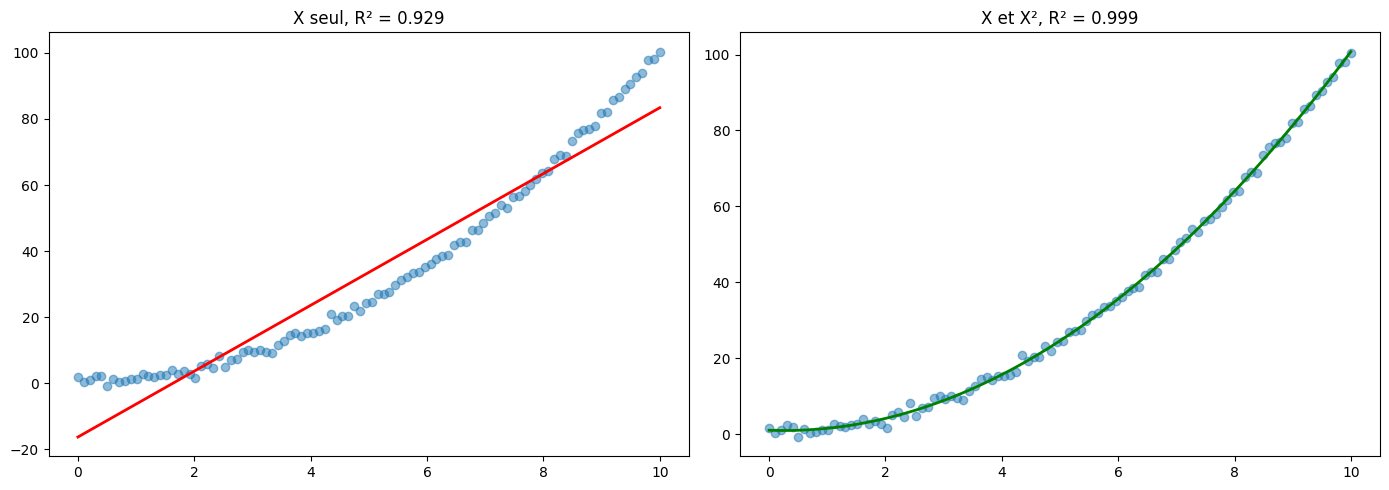

In [30]:
prediction_simple = simple.predict(X)
prediction_augmente = augmente.predict(X_augmente)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(X, y, alpha=0.5)
ax[0].plot(X, prediction_simple, c='red', lw=2)
ax[0].set_title(f'X seul, R² = {simple.score(X, y):.3f}')

ax[1].scatter(X, y, alpha=0.5)
ax[1].plot(X, prediction_augmente, c='green', lw=2)
ax[1].set_title(f'X et X², R² = {augmente.score(X_augmente, y):.3f}')

plt.tight_layout()
plt.show()

In [31]:
print('équation apprise :')
print(f'y = {augmente.coef_.ravel()[1]:.3f} · X²  '
      f'+ {augmente.coef_.ravel()[0]:.3f} · X  '
      f'+ {augmente.intercept_[0]:.3f}')

équation apprise :
y = 1.052 · X²  + -0.548 · X  + 1.063


In [32]:
from sklearn.preprocessing import PolynomialFeatures

X_poly = PolynomialFeatures(degree=2).fit_transform(X)
print('colonnes générées :', X_poly.shape[1]) # 1, X, X²

modele_poly = LinearRegression().fit(X_poly, y)
print('R² :', round(modele_poly.score(X_poly, y), 4))

colonnes générées : 3
R² : 0.9991


In [33]:
# Exercice 2

In [34]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Préparation
titanic = sns.load_dataset('titanic')[['survived', 'pclass', 'age', 'sex']].copy()
titanic = titanic.dropna()
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})

y = titanic['survived']
X = titanic.drop('survived', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

In [36]:
modeles = {
    'KNN': KNeighborsClassifier(),
    'Logistique': LogisticRegression(max_iter=1000),
    'Forêt': RandomForestClassifier(random_state=0),
}

print(f'{"modèle":<12} {"train":>7} {"test":>7} {"écart":>7}')
print('-' * 35)

for nom, model in modeles.items():
    model.fit(X_train, y_train)
    score_train = model.score(X_train, y_train)
    score_test = model.score(X_test, y_test)
    ecart = score_train - score_test
    print(f'{nom:<12} {score_train:>7.3f} {score_test:>7.3f} {ecart:>7.3f}')

modèle         train    test   écart
-----------------------------------
KNN            0.841   0.734   0.106
Logistique     0.774   0.853  -0.079
Forêt          0.895   0.804   0.091


In [37]:
# Exercice 3

In [38]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=1)
model.fit(X, y)
print('Score :', model.score(X, y))

Score : 0.8235294117647058


In [39]:
# Le point le plus proche d'un point est lui-même
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=1).fit(X)
distances, indices = nn.kneighbors(X)
print('distance au plus proche voisin :', distances[:5].ravel())

distance au plus proche voisin : [0. 0. 0. 0. 0.]


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train, y_train)

print('score train :', round(model.score(X_train, y_train), 3))
print('score test  :', round(model.score(X_test, y_test), 3))

score train : 0.874
score test  : 0.769


In [41]:
for k in [1, 5, 15, 30]:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    print(f'k={k:<3} train={m.score(X_train, y_train):.3f}  '
          f'test={m.score(X_test, y_test):.3f}')

k=1   train=0.874  test=0.769
k=5   train=0.841  test=0.734
k=15  train=0.788  test=0.762
k=30  train=0.706  test=0.699
